In [ ]:
import json
import math
import os
import subprocess
import sys
from collections import Counter
from pathlib import Path


REFINED_DIR = Path("/content/drive/MyDrive/drugtarget_local/refined")
OUTPUTS_DIR = Path("/content/drive/MyDrive/drugtarget_local/outputs")
ML_OUTPUTS_DIR = OUTPUTS_DIR / "ml_inputs"
LABEL_CSV = Path("/content/drive/MyDrive/drugtarget_local/config/gdc_sample_labels_from_metadata.csv")

BATCH_SIZE_DA = 250_000
BATCH_SIZE_ML = 200_000
STRING_CONFIDENCE = 700
BETWEENNESS_TOP_N = 400
BETWEENNESS_K = 48
TOP_N_TARGETS = 100
N_CLUSTERS = 5
MAX_ML_FEATURES = 2000
MIN_PREVALENCE = 0.85
MIN_MEAN_LOG2_TPM = 0.5
RANDOM_STATE = 42


def setup_colab():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as exc:
        print("Drive mount skipped or unavailable:", exc)

    packages = [
        "pandas",
        "numpy",
        "pyarrow",
        "scipy",
        "scikit-learn",
        "statsmodels",
        "networkx",
        "joblib",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])


setup_colab()

import joblib
import networkx as nx
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests


GDC_ANNOTATE = REFINED_DIR / "gdc" / "annotate.parquet"
GEO_ANNOTATE = REFINED_DIR / "geo" / "annotate.parquet"
STRING_NODES = REFINED_DIR / "STRING" / "nodes_gene.parquet"
STRING_EDGES = REFINED_DIR / "STRING" / "edges_gene.parquet"


def require_paths():
    required = [GDC_ANNOTATE, GEO_ANNOTATE, STRING_NODES, STRING_EDGES]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing refined inputs:\n" + "\n".join(missing))
    OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
    ML_OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
    if not LABEL_CSV.exists():
        print("IMPORTANT: authoritative label CSV not found.")
        print("Expected:", LABEL_CSV)
        print("The script can still run using refined sample_type, but ML labels may be wrong.")
        print("Recommended: upload config/gdc_sample_labels_from_metadata.csv from the project to Drive first.")


def load_gdc_sample_labels() -> pd.DataFrame:
    if LABEL_CSV.exists():
        labels = pd.read_csv(LABEL_CSV)
        labels["sample_type"] = labels["sample_type"].astype(str).str.lower().str.strip()
        labels = labels[labels["sample_type"].isin(["tumor", "normal"])].copy()
        labels["label"] = labels["sample_type"].map({"normal": 0, "tumor": 1}).astype(int)
        return labels.sort_values("file_id").reset_index(drop=True)

    dataset = ds.dataset(str(GDC_ANNOTATE), format="parquet")
    columns = ["file_id", "case_id", "survival_time", "days_to_death", "sample_type"]
    labels = dataset.to_table(columns=columns).to_pandas().drop_duplicates("file_id")
    labels["sample_type"] = labels["sample_type"].astype(str).str.lower().str.strip()
    labels = labels[labels["sample_type"].isin(["tumor", "normal"])].copy()
    labels["label"] = labels["sample_type"].map({"normal": 0, "tumor": 1}).astype(int)
    labels["gdc_sample_type_raw"] = labels["sample_type"].map({"tumor": "refined:tumor", "normal": "refined:normal"})
    counts = labels["sample_type"].value_counts().to_dict()
    print("WARNING: using fallback labels from refined gdc/annotate.parquet:", counts)
    print("For reliable ML, copy config/gdc_sample_labels_from_metadata.csv to:")
    print(" ", LABEL_CSV)
    return labels.sort_values("file_id").reset_index(drop=True)


def merge_group_accumulator(acc: pd.DataFrame | None, batch_stats: pd.DataFrame) -> pd.DataFrame:
    if acc is None:
        return batch_stats
    merged = acc.merge(batch_stats, on=["gene_name_norm", "group"], how="outer", suffixes=("_old", "_new"))
    for col in ["sum_raw", "sum_log", "sumsq_log", "count"]:
        merged[col] = merged[f"{col}_old"].fillna(0) + merged[f"{col}_new"].fillna(0)
    merged["gene_name"] = merged["gene_name_old"].combine_first(merged["gene_name_new"])
    merged["gene_id"] = merged["gene_id_old"].combine_first(merged["gene_id_new"])
    return merged[["gene_name_norm", "group", "gene_name", "gene_id", "sum_raw", "sum_log", "sumsq_log", "count"]]


def welch_from_summary(mean_a, var_a, n_a, mean_b, var_b, n_b) -> pd.Series:
    se = np.sqrt((var_a / n_a) + (var_b / n_b))
    t_stat = (mean_a - mean_b) / se.replace(0, np.nan)
    df_num = ((var_a / n_a) + (var_b / n_b)) ** 2
    df_den = ((var_a / n_a) ** 2 / (n_a - 1)) + ((var_b / n_b) ** 2 / (n_b - 1))
    dof = df_num / df_den.replace(0, np.nan)
    return pd.Series(2 * stats.t.sf(np.abs(t_stat), dof), index=mean_a.index).fillna(1.0)


def build_gdc_de() -> tuple[pd.DataFrame, dict]:
    print("Building GDC differential expression...")
    labels = load_gdc_sample_labels()
    label_lookup = labels[["file_id", "sample_type"]].copy()
    label_counts = labels["sample_type"].value_counts().to_dict()
    print("  labels:", label_counts)

    dataset = ds.dataset(str(GDC_ANNOTATE), format="parquet")
    accumulator = None
    for i, batch in enumerate(dataset.scanner(columns=["file_id", "gene_id", "gene_name", "tpm_unstranded"], batch_size=BATCH_SIZE_DA).to_batches(), 1):
        frame = batch.to_pandas()
        frame = frame.merge(label_lookup, on="file_id", how="inner")
        frame = frame.dropna(subset=["gene_name", "tpm_unstranded", "sample_type"])
        frame["gene_name_norm"] = frame["gene_name"].astype(str).str.upper().str.strip()
        frame["group"] = frame["sample_type"].astype(str).str.lower().str.strip()
        frame["expr_raw"] = pd.to_numeric(frame["tpm_unstranded"], errors="coerce")
        frame = frame.dropna(subset=["expr_raw"])
        frame["expr_log"] = np.log2(frame["expr_raw"] + 1)
        frame["expr_log_sq"] = frame["expr_log"] ** 2
        stats_batch = (
            frame.groupby(["gene_name_norm", "group"], observed=True)
            .agg(
                gene_name=("gene_name", "first"),
                gene_id=("gene_id", "first"),
                sum_raw=("expr_raw", "sum"),
                sum_log=("expr_log", "sum"),
                sumsq_log=("expr_log_sq", "sum"),
                count=("expr_raw", "count"),
            )
            .reset_index()
        )
        accumulator = merge_group_accumulator(accumulator, stats_batch)
        if i % 10 == 0:
            print("  GDC batches:", i)

    wide = accumulator.pivot(index="gene_name_norm", columns="group")
    wide.columns = [f"{metric}_{group}" for metric, group in wide.columns]
    wide = wide.reset_index()
    for group in ["tumor", "normal"]:
        wide[f"mean_raw_{group}"] = wide[f"sum_raw_{group}"] / wide[f"count_{group}"]
        wide[f"mean_log_{group}"] = wide[f"sum_log_{group}"] / wide[f"count_{group}"]
        numerator = wide[f"sumsq_log_{group}"] - (wide[f"sum_log_{group}"] ** 2 / wide[f"count_{group}"])
        wide[f"var_log_{group}"] = (numerator / (wide[f"count_{group}"] - 1)).clip(lower=0)

    wide = wide[(wide["count_tumor"] >= 5) & (wide["count_normal"] >= 5)].copy()
    wide["gdc_log2_fc"] = np.log2((wide["mean_raw_tumor"] + 1) / (wide["mean_raw_normal"] + 1))
    wide["gdc_p_value"] = welch_from_summary(
        wide["mean_log_tumor"], wide["var_log_tumor"], wide["count_tumor"],
        wide["mean_log_normal"], wide["var_log_normal"], wide["count_normal"],
    )
    wide["gdc_adj_p_value"] = multipletests(wide["gdc_p_value"].fillna(1), method="fdr_bh")[1]
    wide["gdc_neg_log10_fdr"] = -np.log10(wide["gdc_adj_p_value"].clip(lower=1e-300))
    wide["gdc_abs_log2_fc"] = wide["gdc_log2_fc"].abs()
    wide["gdc_expression_status"] = np.select(
        [
            (wide["gdc_adj_p_value"] < 0.05) & (wide["gdc_log2_fc"] >= 1.5),
            (wide["gdc_adj_p_value"] < 0.05) & (wide["gdc_log2_fc"] <= -1.5),
            (wide["gdc_p_value"] < 0.05) & (wide["gdc_log2_fc"] >= 1.0),
            (wide["gdc_p_value"] < 0.05) & (wide["gdc_log2_fc"] <= -1.0),
        ],
        ["FDR Up-regulated", "FDR Down-regulated", "Nominal Up-regulated", "Nominal Down-regulated"],
        default="Not significant",
    )
    de = wide[
        [
            "gene_name_norm", "gene_name_tumor", "gene_id_tumor", "count_tumor", "count_normal",
            "mean_raw_tumor", "mean_raw_normal", "mean_log_tumor", "mean_log_normal",
            "gdc_log2_fc", "gdc_abs_log2_fc", "gdc_p_value", "gdc_adj_p_value",
            "gdc_neg_log10_fdr", "gdc_expression_status",
        ]
    ].rename(columns={"gene_name_tumor": "gene_name", "gene_id_tumor": "gene_id"})
    return de, {"label_source": "refined gdc/annotate.parquet sample_type", "file_counts": {k: int(v) for k, v in label_counts.items()}}


def build_geo_validation() -> pd.DataFrame:
    print("Building GEO stage validation...")
    dataset = ds.dataset(str(GEO_ANNOTATE), format="parquet")
    early = {"I", "IA", "IB"}
    advanced = {"II", "IIA", "IIB", "III", "IIIA", "IIIB", "IV"}
    accumulator = None
    for i, batch in enumerate(dataset.scanner(columns=["Gene_Symbol", "Expression_Value", "Stage_consensus_MD"], batch_size=BATCH_SIZE_DA).to_batches(), 1):
        frame = batch.to_pandas().dropna(subset=["Gene_Symbol", "Expression_Value", "Stage_consensus_MD"])
        frame["gene_name_norm"] = frame["Gene_Symbol"].astype(str).str.upper().str.strip()
        stage = frame["Stage_consensus_MD"].astype(str).str.upper().str.strip()
        frame["group"] = np.where(stage.isin(advanced), "advanced", np.where(stage.isin(early), "early", None))
        frame = frame.dropna(subset=["group"])
        frame["expr"] = pd.to_numeric(frame["Expression_Value"], errors="coerce")
        frame = frame.dropna(subset=["expr"])
        frame["expr_sq"] = frame["expr"] ** 2
        stats_batch = (
            frame.groupby(["gene_name_norm", "group"], observed=True)
            .agg(
                gene_name=("Gene_Symbol", "first"),
                gene_id=("Gene_Symbol", "first"),
                sum_raw=("expr", "sum"),
                sum_log=("expr", "sum"),
                sumsq_log=("expr_sq", "sum"),
                count=("expr", "count"),
            )
            .reset_index()
        )
        accumulator = merge_group_accumulator(accumulator, stats_batch)
        if i % 10 == 0:
            print("  GEO batches:", i)

    wide = accumulator.pivot(index="gene_name_norm", columns="group")
    wide.columns = [f"{metric}_{group}" for metric, group in wide.columns]
    wide = wide.reset_index()
    wide = wide[(wide["count_advanced"] >= 20) & (wide["count_early"] >= 20)].copy()
    for group in ["advanced", "early"]:
        wide[f"mean_{group}"] = wide[f"sum_raw_{group}"] / wide[f"count_{group}"]
        numerator = wide[f"sumsq_log_{group}"] - (wide[f"sum_log_{group}"] ** 2 / wide[f"count_{group}"])
        wide[f"var_{group}"] = (numerator / (wide[f"count_{group}"] - 1)).clip(lower=0)
    wide["geo_stage_diff_advanced_vs_early"] = wide["mean_advanced"] - wide["mean_early"]
    wide["geo_p_value"] = welch_from_summary(
        wide["mean_advanced"], wide["var_advanced"], wide["count_advanced"],
        wide["mean_early"], wide["var_early"], wide["count_early"],
    )
    wide["geo_adj_p_value"] = multipletests(wide["geo_p_value"].fillna(1), method="fdr_bh")[1]
    return wide[
        [
            "gene_name_norm", "count_advanced", "count_early", "mean_advanced", "mean_early",
            "geo_stage_diff_advanced_vs_early", "geo_p_value", "geo_adj_p_value",
        ]
    ]


def build_network_features() -> tuple[pd.DataFrame, dict]:
    print("Building STRING network features...")
    nodes = pd.read_parquet(STRING_NODES)
    nodes["gene_name_norm"] = nodes["gene_name_norm"].astype(str).str.upper().str.strip()

    edge_dataset = ds.dataset(str(STRING_EDGES), format="parquet")
    edges = edge_dataset.to_table(
        columns=["gene_name_src", "gene_name_dst", "max_combined_score_gene", "max_edge_weight_gene"],
        filter=pc.field("max_combined_score_gene") >= STRING_CONFIDENCE,
    ).to_pandas()
    edges["gene_name_src"] = edges["gene_name_src"].astype(str).str.upper().str.strip()
    edges["gene_name_dst"] = edges["gene_name_dst"].astype(str).str.upper().str.strip()
    edges = edges[edges["gene_name_src"] != edges["gene_name_dst"]].dropna()

    graph = nx.Graph()
    graph.add_nodes_from(nodes["gene_name_norm"].dropna().unique())
    graph.add_weighted_edges_from(edges[["gene_name_src", "gene_name_dst", "max_edge_weight_gene"]].itertuples(index=False, name=None))
    print(f"  graph nodes={graph.number_of_nodes():,}, edges={graph.number_of_edges():,}")

    pagerank = nx.pagerank(graph, weight="weight", max_iter=100, tol=1e-06)
    high_degree_nodes = nodes.sort_values("weighted_degree_gene", ascending=False)["gene_name_norm"].head(BETWEENNESS_TOP_N).tolist()
    sub_nodes = set(high_degree_nodes)
    for node in high_degree_nodes:
        if node in graph:
            sub_nodes.update(graph.neighbors(node))
    subgraph = graph.subgraph(sub_nodes).copy()
    k = min(BETWEENNESS_K, subgraph.number_of_nodes())
    print(f"  betweenness subgraph nodes={subgraph.number_of_nodes():,}, edges={subgraph.number_of_edges():,}, k={k}")
    betweenness = nx.betweenness_centrality(subgraph, k=k, weight="weight", seed=42) if k > 0 else {}

    features = nodes[["gene_name_norm", "gene_id", "gene_name", "degree_gene", "weighted_degree_gene", "protein_count"]].copy()
    features["pagerank"] = features["gene_name_norm"].map(pagerank).fillna(0.0)
    features["betweenness_centrality"] = features["gene_name_norm"].map(betweenness).fillna(0.0)
    summary = {
        "confidence_threshold": STRING_CONFIDENCE,
        "edge_rows_after_filter": int(len(edges)),
        "graph_nodes": int(graph.number_of_nodes()),
        "graph_edges": int(graph.number_of_edges()),
        "betweenness_subgraph_nodes": int(subgraph.number_of_nodes()),
        "betweenness_subgraph_edges": int(subgraph.number_of_edges()),
    }
    return features, summary


def minmax(series: pd.Series) -> pd.Series:
    series = pd.to_numeric(series, errors="coerce").fillna(0)
    lo, hi = series.min(), series.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or math.isclose(hi, lo):
        return pd.Series(0.0, index=series.index)
    return (series - lo) / (hi - lo)


def add_scores(master: pd.DataFrame) -> pd.DataFrame:
    print("Adding PCA, KMeans, and target score...")
    gene = master["gene_name_norm"].astype(str)
    housekeeping = {"ACTB", "B2M", "GAPDH", "GUSB", "HPRT1", "LDHA", "PGK1", "PPIA", "RPLP0", "TBP", "TFRC", "TUBA1B", "TUBB", "YWHAZ"}
    blood = {"ALB", "APOA1", "APOA2", "APOB", "FGA", "FGB", "FGG", "HBA1", "HBA2", "HBB", "HP"}
    master["target_penalty_reason"] = np.select(
        [gene.isin(housekeeping), gene.isin(blood), gene.str.match(r"^(RPL|RPS|MT-|HLA-)")],
        ["housekeeping_gene", "plasma_or_blood_marker", "broad_background_family"],
        default="none",
    )
    master["target_penalty_factor"] = np.where(master["target_penalty_reason"].eq("none"), 1.0, 0.35)
    master["geo_direction_match"] = np.sign(master["gdc_log2_fc"].fillna(0)) == np.sign(master["geo_stage_diff_advanced_vs_early"].fillna(0))
    master["geo_validation_status"] = np.select(
        [
            master["geo_adj_p_value"].isna(),
            (master["geo_adj_p_value"] < 0.05) & master["geo_direction_match"],
            (master["geo_adj_p_value"] < 0.05) & ~master["geo_direction_match"],
        ],
        ["missing_geo", "validated", "conflicting"],
        default="geo_weak_signal",
    )
    master["geo_validation_bonus"] = np.select(
        [
            master["geo_validation_status"].eq("validated"),
            master["geo_validation_status"].eq("geo_weak_signal") & master["geo_direction_match"],
            master["geo_validation_status"].eq("conflicting"),
        ],
        [1.0, 0.5, -0.25],
        default=0.0,
    )

    feature_cols = ["gdc_abs_log2_fc", "gdc_neg_log10_fdr", "pagerank", "weighted_degree_gene", "degree_gene", "betweenness_centrality", "geo_validation_bonus"]
    matrix = master[feature_cols].replace([np.inf, -np.inf], np.nan)
    scaled = StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(matrix))
    pca_values = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(scaled)
    master["pca_1"] = pca_values[:, 0]
    master["pca_2"] = pca_values[:, 1]
    master["cluster_id"] = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20).fit_predict(scaled)

    master["gdc_neg_log10_p"] = -np.log10(master["gdc_p_value"].clip(lower=1e-300))
    tumor_total = max(float(master["count_tumor"].max()), 1.0)
    normal_total = max(float(master["count_normal"].max()), 1.0)
    master["sample_prevalence_score"] = np.minimum(master["count_tumor"] / tumor_total, master["count_normal"] / normal_total).clip(0, 1)
    effect_score = (master["gdc_abs_log2_fc"] / 2.5).clip(0, 1)
    stat_score = (master["gdc_neg_log10_p"] / 3.0).clip(0, 1)
    master["expression_evidence_score"] = (0.60 * effect_score + 0.40 * stat_score) * master["sample_prevalence_score"]
    master["network_context_score"] = 0.40 * minmax(master["pagerank"]) + 0.35 * minmax(master["weighted_degree_gene"]) + 0.25 * minmax(master["betweenness_centrality"])
    master["geo_component_score"] = ((master["geo_validation_bonus"] + 0.25) / 1.25).clip(0, 1)
    master["de_priority_gate"] = np.select(
        [
            (master["gdc_adj_p_value"] < 0.05) & (master["gdc_abs_log2_fc"] >= 1.5),
            (master["gdc_p_value"] < 0.05) & (master["gdc_abs_log2_fc"] >= 1.0),
            master["gdc_abs_log2_fc"] >= 1.5,
        ],
        [1.0, 0.65, 0.45],
        default=0.20,
    )
    master["target_score_raw"] = (
        0.58 * master["expression_evidence_score"]
        + 0.22 * master["network_context_score"] * master["de_priority_gate"]
        + 0.15 * master["geo_component_score"]
        + 0.05 * master["sample_prevalence_score"]
    )
    master["target_score"] = master["target_score_raw"] * master["target_penalty_factor"]
    master["target_rank"] = master["target_score"].rank(method="dense", ascending=False).astype(int)
    master["evidence_level"] = np.select(
        [(master["target_rank"] <= 50) & master["geo_validation_status"].eq("validated"), master["target_rank"] <= 100, master["target_rank"] <= 500],
        ["high", "medium", "exploratory"],
        default="background",
    )
    return master.sort_values("target_rank")


def build_visualization_artifacts(master: pd.DataFrame):
    print("Building visualization artifacts...")
    master[["gene_name_norm", "gene_name", "gdc_log2_fc", "gdc_p_value", "gdc_adj_p_value", "gdc_neg_log10_fdr", "gdc_expression_status", "target_score", "target_rank"]].to_parquet(OUTPUTS_DIR / "volcano_points.parquet", index=False)

    top_genes = master.head(TOP_N_TARGETS)["gene_name_norm"].tolist()
    labels = load_gdc_sample_labels()[["file_id", "sample_type"]]
    gene_set = set(top_genes)
    chunks = []
    dataset = ds.dataset(str(GDC_ANNOTATE), format="parquet")
    for batch in dataset.scanner(columns=["file_id", "gene_name", "tpm_unstranded"], batch_size=200_000).to_batches():
        frame = batch.to_pandas()
        frame["gene_name_norm"] = frame["gene_name"].astype(str).str.upper().str.strip()
        frame = frame[frame["gene_name_norm"].isin(gene_set)]
        if not frame.empty:
            chunks.append(frame.merge(labels, on="file_id", how="inner")[["file_id", "sample_type", "gene_name_norm", "tpm_unstranded"]])
    if chunks:
        heatmap_long = pd.concat(chunks, ignore_index=True)
        heatmap_long["log2_tpm"] = np.log2(pd.to_numeric(heatmap_long["tpm_unstranded"], errors="coerce") + 1)
        heatmap_matrix = heatmap_long.pivot_table(index="gene_name_norm", columns="file_id", values="log2_tpm", aggfunc="mean")
        heatmap_matrix.to_parquet(OUTPUTS_DIR / "heatmap_matrix.parquet")
        heatmap_matrix.T.corr().to_parquet(OUTPUTS_DIR / "gene_correlation_matrix.parquet")

    edge_dataset = ds.dataset(str(STRING_EDGES), format="parquet")
    network_edges = edge_dataset.to_table(
        columns=["gene_name_src", "gene_name_dst", "max_edge_weight_gene", "max_combined_score_gene"],
        filter=(pc.field("max_combined_score_gene") >= STRING_CONFIDENCE) & pc.field("gene_name_src").isin(top_genes) & pc.field("gene_name_dst").isin(top_genes),
    ).to_pandas()
    lookup = master.set_index("gene_name_norm")
    nodes = [{"data": {"id": g, "label": g, "target_score": float(lookup.loc[g, "target_score"]), "pagerank": float(lookup.loc[g, "pagerank"]), "rank": int(lookup.loc[g, "target_rank"])}} for g in top_genes]
    edges = [{"data": {"source": str(r.gene_name_src).upper(), "target": str(r.gene_name_dst).upper(), "weight": float(r.max_edge_weight_gene), "combined_score": float(r.max_combined_score_gene)}} for r in network_edges.itertuples(index=False)]
    (OUTPUTS_DIR / "network_subgraph.json").write_text(json.dumps({"status": "success", "nodes": nodes, "edges": edges}, indent=2), encoding="utf-8")


def run_da() -> pd.DataFrame:
    require_paths()
    gdc_de, label_summary = build_gdc_de()
    geo = build_geo_validation()
    network, network_summary = build_network_features()
    master = gdc_de.merge(geo, on="gene_name_norm", how="left").merge(network, on="gene_name_norm", how="left", suffixes=("", "_string"))
    master["gene_id"] = master["gene_id"].combine_first(master["gene_id_string"])
    master["gene_name"] = master["gene_name"].combine_first(master["gene_name_string"])
    master = master.drop(columns=[c for c in ["gene_id_string", "gene_name_string"] if c in master.columns])
    for col in ["degree_gene", "weighted_degree_gene", "protein_count", "pagerank", "betweenness_centrality"]:
        master[col] = master[col].fillna(0)
    master = add_scores(master)
    master.to_parquet(OUTPUTS_DIR / "master_biomarker_features.parquet", index=False)
    master.head(TOP_N_TARGETS).to_csv(OUTPUTS_DIR / "top_drug_targets.csv", index=False)
    build_visualization_artifacts(master)
    summary = {
        "parameters": {
            "batch_size_da": BATCH_SIZE_DA,
            "string_confidence": STRING_CONFIDENCE,
            "betweenness_top_n": BETWEENNESS_TOP_N,
            "betweenness_k": BETWEENNESS_K,
            "top_n": TOP_N_TARGETS,
        },
        "gdc_labels": label_summary,
        "network": network_summary,
        "master_rows": int(len(master)),
        "expression_status_counts": Counter(master["gdc_expression_status"]).most_common(),
        "geo_validation_counts": Counter(master["geo_validation_status"]).most_common(),
        "top_20_targets": master.head(20)[["gene_name_norm", "target_rank", "target_score", "gdc_log2_fc", "gdc_adj_p_value", "geo_validation_status"]].to_dict(orient="records"),
    }
    (OUTPUTS_DIR / "da_run_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    print("DA done:", OUTPUTS_DIR)
    return master


def build_splits(labels: pd.DataFrame) -> pd.DataFrame:
    train_val, test = train_test_split(labels, test_size=0.15, stratify=labels["label"], random_state=RANDOM_STATE)
    train, val = train_test_split(train_val, test_size=0.1765, stratify=train_val["label"], random_state=RANDOM_STATE)
    split_map = {fid: "train" for fid in train["file_id"]}
    split_map.update({fid: "val" for fid in val["file_id"]})
    split_map.update({fid: "test" for fid in test["file_id"]})
    labels = labels.copy()
    labels["split"] = labels["file_id"].map(split_map)
    return labels


def select_features_from_train(labels: pd.DataFrame) -> pd.DataFrame:
    print("Selecting ML genes from train split only...")
    train_files = set(labels.loc[labels["split"] == "train", "file_id"])
    n_train = len(train_files)
    dataset = ds.dataset(str(GDC_ANNOTATE), format="parquet")
    accumulator = None
    for i, batch in enumerate(dataset.scanner(columns=["file_id", "gene_id", "gene_name", "tpm_unstranded"], batch_size=BATCH_SIZE_ML).to_batches(), 1):
        frame = batch.to_pandas()
        frame = frame[frame["file_id"].isin(train_files)]
        if frame.empty:
            continue
        frame = frame.dropna(subset=["gene_name", "tpm_unstranded"])
        frame["gene_name_norm"] = frame["gene_name"].astype(str).str.upper().str.strip()
        frame["log2_tpm"] = np.log2(pd.to_numeric(frame["tpm_unstranded"], errors="coerce") + 1)
        frame = frame.dropna(subset=["log2_tpm"])
        frame["log2_tpm_sq"] = frame["log2_tpm"] ** 2
        stats_batch = frame.groupby("gene_name_norm", observed=True).agg(
            gene_name=("gene_name", "first"),
            gene_id=("gene_id", "first"),
            observed_train_samples=("file_id", "nunique"),
            mean_log2_tpm_sum=("log2_tpm", "sum"),
            sumsq_log2_tpm=("log2_tpm_sq", "sum"),
            row_count=("log2_tpm", "count"),
        ).reset_index()
        if accumulator is None:
            accumulator = stats_batch
        else:
            merged = accumulator.merge(stats_batch, on="gene_name_norm", how="outer", suffixes=("_old", "_new"))
            merged["gene_name"] = merged["gene_name_old"].combine_first(merged["gene_name_new"])
            merged["gene_id"] = merged["gene_id_old"].combine_first(merged["gene_id_new"])
            for col in ["observed_train_samples", "mean_log2_tpm_sum", "sumsq_log2_tpm", "row_count"]:
                merged[col] = merged[f"{col}_old"].fillna(0) + merged[f"{col}_new"].fillna(0)
            accumulator = merged[["gene_name_norm", "gene_name", "gene_id", "observed_train_samples", "mean_log2_tpm_sum", "sumsq_log2_tpm", "row_count"]]
        if i % 10 == 0:
            print("  feature-selection batches:", i)

    features = accumulator.copy()
    features["train_prevalence"] = features["observed_train_samples"] / n_train
    features["mean_log2_tpm_train"] = features["mean_log2_tpm_sum"] / features["row_count"]
    var_num = features["sumsq_log2_tpm"] - (features["mean_log2_tpm_sum"] ** 2 / features["row_count"])
    features["variance_log2_tpm_train"] = (var_num / (features["row_count"] - 1)).clip(lower=0).fillna(0)
    features = features[(features["train_prevalence"] >= MIN_PREVALENCE) & (features["mean_log2_tpm_train"] >= MIN_MEAN_LOG2_TPM)]
    features = features.sort_values("variance_log2_tpm_train", ascending=False).head(MAX_ML_FEATURES)
    features["feature_rank"] = np.arange(1, len(features) + 1)
    return features[["feature_rank", "gene_name_norm", "gene_name", "gene_id", "train_prevalence", "mean_log2_tpm_train", "variance_log2_tpm_train"]]


def pivot_selected_genes(labels: pd.DataFrame, selected: pd.DataFrame) -> pd.DataFrame:
    print("Pivoting selected genes...")
    selected_genes = set(selected["gene_name_norm"])
    chunks = []
    dataset = ds.dataset(str(GDC_ANNOTATE), format="parquet")
    for i, batch in enumerate(dataset.scanner(columns=["file_id", "gene_name", "tpm_unstranded"], batch_size=BATCH_SIZE_ML).to_batches(), 1):
        frame = batch.to_pandas()
        frame["gene_name_norm"] = frame["gene_name"].astype(str).str.upper().str.strip()
        frame = frame[frame["gene_name_norm"].isin(selected_genes)]
        if not frame.empty:
            frame["log2_tpm"] = np.log2(pd.to_numeric(frame["tpm_unstranded"], errors="coerce") + 1)
            chunks.append(frame[["file_id", "gene_name_norm", "log2_tpm"]])
        if i % 10 == 0:
            print("  pivot batches:", i)
    long = pd.concat(chunks, ignore_index=True)
    matrix = long.pivot_table(index="file_id", columns="gene_name_norm", values="log2_tpm", aggfunc="mean")
    return matrix.reindex(index=labels["file_id"], columns=selected["gene_name_norm"])


def run_ml_inputs() -> tuple[pd.DataFrame, pd.DataFrame]:
    labels = build_splits(load_gdc_sample_labels())
    selected = select_features_from_train(labels)
    matrix = pivot_selected_genes(labels, selected)
    labels_ordered = labels.set_index("file_id").reindex(matrix.index).reset_index()
    matrix.to_parquet(ML_OUTPUTS_DIR / "gdc_expression_top_genes_all.parquet")
    labels_ordered.to_parquet(ML_OUTPUTS_DIR / "gdc_labels_splits.parquet", index=False)
    for split in ["train", "val", "test"]:
        ids = labels_ordered.loc[labels_ordered["split"] == split, "file_id"]
        matrix.loc[ids].to_parquet(ML_OUTPUTS_DIR / f"X_{split}.parquet")
        labels_ordered[labels_ordered["split"] == split].to_parquet(ML_OUTPUTS_DIR / f"y_{split}.parquet", index=False)
    selected.to_csv(ML_OUTPUTS_DIR / "selected_gene_features.csv", index=False)

    master = pd.read_parquet(OUTPUTS_DIR / "master_biomarker_features.parquet")
    target_cols = [
        "gene_name_norm", "gdc_abs_log2_fc", "gdc_neg_log10_p", "gdc_neg_log10_fdr",
        "sample_prevalence_score", "expression_evidence_score", "network_context_score",
        "geo_component_score", "de_priority_gate", "degree_gene", "weighted_degree_gene",
        "pagerank", "betweenness_centrality", "pca_1", "pca_2", "cluster_id",
        "target_score_raw", "target_penalty_reason", "target_penalty_factor",
        "target_score", "target_rank", "evidence_level",
    ]
    master[[c for c in target_cols if c in master.columns]].to_parquet(ML_OUTPUTS_DIR / "target_prioritization_features.parquet", index=False)
    manifest = {
        "task": "GDC tumor_vs_normal sample classification input",
        "label_source": "refined gdc/annotate.parquet sample_type",
        "anti_leakage_design": [
            "Train/validation/test split is created before feature selection.",
            "Gene selection uses only train split expression distributions.",
            "Selection is unsupervised: prevalence, mean expression, and train variance only.",
            "No tumor/normal differential expression score is used to choose sample-classification features.",
        ],
        "shape_all": [int(matrix.shape[0]), int(matrix.shape[1])],
        "split_counts": labels_ordered.groupby(["split", "sample_type"]).size().unstack(fill_value=0).to_dict(),
        "selected_feature_count": int(len(selected)),
    }
    (ML_OUTPUTS_DIR / "ml_input_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    print("ML inputs done:", ML_OUTPUTS_DIR)
    return matrix, labels_ordered


def load_split(split: str):
    x = pd.read_parquet(ML_OUTPUTS_DIR / f"X_{split}.parquet")
    y_frame = pd.read_parquet(ML_OUTPUTS_DIR / f"y_{split}.parquet")
    y = y_frame.set_index("file_id").reindex(x.index)["label"].astype(int)
    return x, y


def run_baseline_model():
    print("Training baseline Logistic Regression...")
    x_train, y_train = load_split("train")
    x_val, y_val = load_split("val")
    x_test, y_test = load_split("test")
    candidates = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
    best_model, best_result = None, None
    val_results = []

    def build_model(c):
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(C=c, penalty="l2", solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE, max_iter=2000)),
        ])

    def evaluate(model, x, y):
        proba = model.predict_proba(x)[:, 1]
        pred = (proba >= 0.5).astype(int)
        return {
            "accuracy": float(accuracy_score(y, pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
            "roc_auc": float(roc_auc_score(y, proba)),
            "average_precision": float(average_precision_score(y, proba)),
            "confusion_matrix": confusion_matrix(y, pred).tolist(),
            "classification_report": classification_report(y, pred, target_names=["normal", "tumor"], output_dict=True, zero_division=0),
        }

    for c in candidates:
        model = build_model(c)
        model.fit(x_train, y_train)
        result = evaluate(model, x_val, y_val)
        result["C"] = c
        val_results.append(result)
        if best_result is None or (result["roc_auc"], result["accuracy"]) > (best_result["roc_auc"], best_result["accuracy"]):
            best_result = result
            best_model = model

    test_result = evaluate(best_model, x_test, y_test)
    coef = best_model.named_steps["model"].coef_[0]
    importance = pd.DataFrame({"gene_name_norm": x_train.columns, "coefficient": coef, "abs_coefficient": np.abs(coef)}).sort_values("abs_coefficient", ascending=False)
    importance.to_parquet(ML_OUTPUTS_DIR / "baseline_logistic_feature_importance.parquet", index=False)
    target_features = pd.read_parquet(ML_OUTPUTS_DIR / "target_prioritization_features.parquet")
    importance.rename(columns={"abs_coefficient": "model_importance"}).merge(target_features, on="gene_name_norm", how="left").to_parquet(ML_OUTPUTS_DIR / "model_feature_importance_joined.parquet", index=False)
    joblib.dump(best_model, ML_OUTPUTS_DIR / "baseline_tumor_normal_logistic.joblib")
    metrics = {
        "model": "LogisticRegression L2 class_weight=balanced",
        "selection_protocol": "C selected on validation split only, test evaluated once",
        "best_validation": best_result,
        "validation_grid": val_results,
        "test": test_result,
        "n_features": int(x_train.shape[1]),
        "n_train": int(x_train.shape[0]),
        "n_val": int(x_val.shape[0]),
        "n_test": int(x_test.shape[0]),
    }
    (ML_OUTPUTS_DIR / "baseline_logistic_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    print("Baseline test:", {k: test_result[k] for k in ["accuracy", "balanced_accuracy", "roc_auc", "confusion_matrix"]})
    return metrics


master = run_da()
matrix, labels = run_ml_inputs()
metrics = run_baseline_model()

print("\nDONE")
print("Outputs:", OUTPUTS_DIR)
print("ML outputs:", ML_OUTPUTS_DIR)
print("master:", master.shape)
print("matrix:", matrix.shape)
print("label counts:", labels.groupby(["split", "sample_type"]).size().unstack(fill_value=0).to_dict())
display(pd.read_csv(OUTPUTS_DIR / "top_drug_targets.csv")[["gene_name_norm", "target_rank", "target_score", "gdc_log2_fc", "geo_validation_status"]].head(20))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Building GDC differential expression...
  labels: {'tumor': 492, 'normal': 24}
  GDC batches: 10
  GDC batches: 20
  GDC batches: 30
  GDC batches: 40
Building GEO stage validation...
  GEO batches: 10
  GEO batches: 20
  GEO batches: 30
  GEO batches: 40
Building STRING network features...
  graph nodes=19,175, edges=235,148
  betweenness subgraph nodes=8,794, edges=190,065, k=48
Adding PCA, KMeans, and target score...
Building visualization artifacts...
DA done: /content/drive/MyDrive/drugtarget_local/outputs
Selecting ML genes from train split only...
  feature-selection batches: 10
  feature-selection batches: 20
  feature-selection batches: 30
  feature-selection batches: 40
Pivoting selected genes...
  pivot batches: 10
  pivot batches: 20
  pivot batches: 30
  pivot batches: 40
ML inputs done: /content/drive/MyDrive/drugtarget_local/outputs/ml_inputs
T

,gene_name_norm,target_rank,target_score,gdc_log2_fc,geo_validation_status
0,PLK1,1,0.625682,2.535514,validated
1,CCNB1,2,0.615296,2.747635,validated
2,CDC20,3,0.611913,3.391005,validated
3,CAV1,4,0.610693,-3.373539,validated
4,CCNA2,5,0.608347,2.619287,validated
5,TOP2A,6,0.607436,3.635870,validated
6,AURKB,7,0.605891,2.873065,validated
7,COL1A1,8,0.603799,2.873461,validated
8,EXO1,9,0.603288,2.466786,validated
9,CDCA8,10,0.601270,2.648615,validated


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shapes:
  X_train: (360, 2000) {1: 344, 0: 16}
  X_val:   (78, 2000) {1: 74, 0: 4}
  X_test:  (78, 2000) {1: 74, 0: 4}
Training candidate models...
  [01/34] logistic_l2_C0.003
  [02/34] logistic_l2_C0.01
  [03/34] logistic_l2_C0.03
  [04/34] logistic_l2_C0.1
  [05/34] logistic_l2_C0.3
  [06/34] logistic_l2_C1.0
  [07/34] logistic_elasticnet_C0.003_l10.15
  [08/34] logistic_elasticnet_C0.003_l10.5
  [09/34] logistic_elasticnet_C0.003_l10.85
  [10/34] logistic_elasticnet_C0.01_l10.15
  [11/34] logistic_elasticnet_C0.01_l10.5
  [12/34] logistic_elasticnet_C0.01_l10.85
  [13/34] logistic_elasticnet_C0.03_l10.15
  [14/34] logistic_elasticnet_C0.03_l10.5
  [15/34] logistic_elasticnet_C0.03_l10.85
  [16/34] logistic_elasticnet_C0.1_l10.15
  [17/34] logistic_elasticnet_C0.1_l10.5
  [18/34] logistic_elasticnet_C0.1_l10.85
  [19/34] logistic_elasticnet_C0.3_l10.15
  [

,model_name,selection_score,threshold,accuracy,balanced_accuracy,roc_auc,average_precision,macro_f1,normal_precision,normal_recall,tumor_precision,tumor_recall,confusion_matrix
0,logistic_l2_C0.003,1.020,0.040503,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
1,logistic_l2_C0.01,1.020,0.027001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
2,logistic_l2_C0.03,1.020,0.019590,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
3,logistic_l2_C0.1,1.020,0.014490,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
4,logistic_l2_C0.3,1.020,0.011449,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
5,logistic_l2_C1.0,1.020,0.008843,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
6,logistic_elasticnet_C0.003_l10.15,1.018,0.320181,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
9,logistic_elasticnet_C0.01_l10.15,1.018,0.206531,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
10,logistic_elasticnet_C0.01_l10.5,1.018,0.300698,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
12,logistic_elasticnet_C0.03_l10.15,1.018,0.163263,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"


Extracting feature importance...


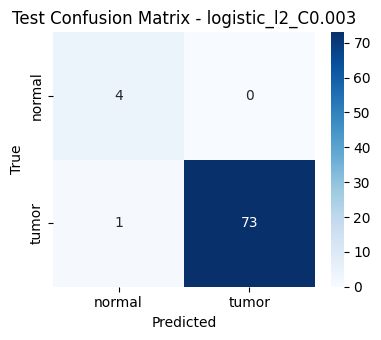


DONE
Best model: logistic_l2_C0.003
Threshold: 0.040503242518162216
Test metrics:
{
  "accuracy": 0.9871794871794872,
  "balanced_accuracy": 0.9932432432432432,
  "roc_auc": 1.0,
  "average_precision": 0.9999999999999998,
  "macro_f1": 0.9410430839002267,
  "confusion_matrix": [
    [
      4,
      0
    ],
    [
      1,
      73
    ]
  ]
}

Saved to: /content/drive/MyDrive/drugtarget_local/outputs/ml_models


,gene_name_norm,model_importance,target_score,target_rank,evidence_level
0,PLA2G4E,0.023949,0.070876,16158,background
1,NCKAP5,0.021443,0.437681,961,background
2,PLA2G7,0.020830,0.246549,9010,background
3,GPM6A,0.020767,0.503257,394,exploratory
4,GPA33,0.020300,0.416408,1304,background
5,NTM,0.019621,0.448708,829,background
6,PYCR1,0.018147,0.519195,279,exploratory
7,HS3ST2,0.017973,0.289967,6232,background
8,LGR4,0.017277,0.509262,360,exploratory
9,RTKN2,0.016518,0.451496,790,background


In [ ]:
import json
import subprocess
import sys
import warnings
from pathlib import Path


OUTPUTS_DIR = Path("/content/drive/MyDrive/drugtarget_local/outputs")
ML_INPUTS_DIR = OUTPUTS_DIR / "ml_inputs"
ML_MODELS_DIR = OUTPUTS_DIR / "ml_models"
RANDOM_STATE = 42


def setup_colab():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as exc:
        print("Drive mount skipped or unavailable:", exc)

    packages = [
        "pandas",
        "numpy",
        "pyarrow",
        "scikit-learn",
        "joblib",
        "matplotlib",
        "seaborn",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])


setup_colab()

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


warnings.filterwarnings("ignore", category=FutureWarning)
ML_MODELS_DIR.mkdir(parents=True, exist_ok=True)


def require_inputs():
    required = [
        ML_INPUTS_DIR / "X_train.parquet",
        ML_INPUTS_DIR / "X_val.parquet",
        ML_INPUTS_DIR / "X_test.parquet",
        ML_INPUTS_DIR / "y_train.parquet",
        ML_INPUTS_DIR / "y_val.parquet",
        ML_INPUTS_DIR / "y_test.parquet",
        ML_INPUTS_DIR / "target_prioritization_features.parquet",
    ]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing ML input files:\n" + "\n".join(missing))


def load_split(split: str):
    x = pd.read_parquet(ML_INPUTS_DIR / f"X_{split}.parquet")
    y_frame = pd.read_parquet(ML_INPUTS_DIR / f"y_{split}.parquet")
    y = y_frame.set_index("file_id").reindex(x.index)["label"].astype(int)
    return x, y, y_frame


def predict_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(x)
        return 1 / (1 + np.exp(-scores))
    raise TypeError("Model has neither predict_proba nor decision_function.")


def threshold_from_validation(y_true, score, metric="balanced_accuracy"):
    thresholds = np.unique(np.quantile(score, np.linspace(0.02, 0.98, 97)))
    best_threshold = 0.5
    best_value = -np.inf
    rows = []
    for threshold in thresholds:
        pred = (score >= threshold).astype(int)
        if metric == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif metric == "macro_f1":
            value = f1_score(y_true, pred, average="macro", zero_division=0)
        else:
            raise ValueError(metric)
        rows.append({"threshold": float(threshold), metric: float(value)})
        if value > best_value:
            best_value = value
            best_threshold = float(threshold)
    return best_threshold, pd.DataFrame(rows)


def evaluate_scores(y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "roc_auc": float(roc_auc_score(y_true, score)),
        "average_precision": float(average_precision_score(y_true, score)),
        "macro_f1": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "normal_precision": float(precision_score(y_true, pred, pos_label=0, zero_division=0)),
        "normal_recall": float(recall_score(y_true, pred, pos_label=0, zero_division=0)),
        "tumor_precision": float(precision_score(y_true, pred, pos_label=1, zero_division=0)),
        "tumor_recall": float(recall_score(y_true, pred, pos_label=1, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, pred, labels=[0, 1]).tolist(),
        "classification_report": classification_report(
            y_true,
            pred,
            labels=[0, 1],
            target_names=["normal", "tumor"],
            output_dict=True,
            zero_division=0,
        ),
    }


def make_candidate_models():
    candidates = {}

    for c in [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]:
        candidates[f"logistic_l2_C{c}"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        C=c,
                        penalty="l2",
                        solver="liblinear",
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        max_iter=3000,
                    ),
                ),
            ]
        )

    for c in [0.003, 0.01, 0.03, 0.1, 0.3]:
        for l1_ratio in [0.15, 0.5, 0.85]:
            candidates[f"logistic_elasticnet_C{c}_l1{l1_ratio}"] = Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    (
                        "model",
                        LogisticRegression(
                            C=c,
                            penalty="elasticnet",
                            solver="saga",
                            l1_ratio=l1_ratio,
                            class_weight="balanced",
                            random_state=RANDOM_STATE,
                            max_iter=5000,
                            n_jobs=-1,
                        ),
                    ),
                ]
            )

    for c in [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]:
        linear_svc = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LinearSVC(
                        C=c,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        max_iter=5000,
                        dual="auto",
                    ),
                ),
            ]
        )
        candidates[f"calibrated_linear_svc_C{c}"] = CalibratedClassifierCV(linear_svc, cv=3, method="sigmoid")

    for max_depth in [4, 6, 8]:
        candidates[f"random_forest_depth{max_depth}"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=600,
                        max_depth=max_depth,
                        min_samples_leaf=3,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

    for max_depth in [4, 6, 8, None]:
        candidates[f"extra_trees_depth{max_depth}"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=800,
                        max_depth=max_depth,
                        min_samples_leaf=2,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

    return candidates


def model_complexity_penalty(name):
    if name.startswith("logistic_l2"):
        return 0.000
    if name.startswith("logistic_elasticnet"):
        return 0.002
    if name.startswith("calibrated_linear_svc"):
        return 0.004
    if name.startswith("random_forest"):
        return 0.010
    if name.startswith("extra_trees"):
        return 0.012
    return 0.020


def train_and_select_models(x_train, y_train, x_val, y_val):
    print("Training candidate models...")
    candidates = make_candidate_models()
    results = []
    fitted = {}
    threshold_tables = {}

    for i, (name, model) in enumerate(candidates.items(), 1):
        print(f"  [{i:02d}/{len(candidates)}] {name}")
        fitted_model = clone(model)
        fitted_model.fit(x_train, y_train)
        val_score = predict_scores(fitted_model, x_val)
        threshold, threshold_table = threshold_from_validation(y_val, val_score, metric="balanced_accuracy")
        metrics = evaluate_scores(y_val, val_score, threshold)
        row = {
            "model_name": name,
            "selection_score": metrics["balanced_accuracy"] + 0.02 * metrics["roc_auc"] - model_complexity_penalty(name),
            **{k: v for k, v in metrics.items() if k not in ["classification_report", "confusion_matrix"]},
            "confusion_matrix": json.dumps(metrics["confusion_matrix"]),
        }
        results.append(row)
        fitted[name] = fitted_model
        threshold_tables[name] = threshold_table

    leaderboard = pd.DataFrame(results).sort_values(
        ["selection_score", "balanced_accuracy", "roc_auc", "macro_f1"],
        ascending=False,
    )
    leaderboard.to_csv(ML_MODELS_DIR / "validation_leaderboard.csv", index=False)
    best_name = leaderboard.iloc[0]["model_name"]
    print("\nBest model by validation:", best_name)
    display(leaderboard.head(15))
    return best_name, fitted[best_name], leaderboard, threshold_tables[best_name]


def fit_final_model(best_model, x_train, y_train, x_val, y_val):
    x_train_val = pd.concat([x_train, x_val], axis=0)
    y_train_val = pd.concat([y_train, y_val], axis=0)
    final_model = clone(best_model)
    final_model.fit(x_train_val, y_train_val)
    val_score = predict_scores(best_model, x_val)
    best_threshold, threshold_table = threshold_from_validation(y_val, val_score, metric="balanced_accuracy")
    return final_model, best_threshold, threshold_table


def extract_feature_importance(model, x_train, y_train, x_test, y_test, model_name):
    print("Extracting feature importance...")
    feature_names = list(x_train.columns)
    importance = pd.DataFrame({"gene_name_norm": feature_names})

    fitted = model
    if isinstance(model, Pipeline):
        final_step = model.named_steps.get("model")
    else:
        final_step = None

    if final_step is not None and hasattr(final_step, "coef_"):
        coef = final_step.coef_[0]
        importance["coefficient"] = coef
        importance["model_importance"] = np.abs(coef)
        importance["importance_type"] = "absolute_coefficient"
    elif final_step is not None and hasattr(final_step, "feature_importances_"):
        importance["model_importance"] = final_step.feature_importances_
        importance["importance_type"] = "tree_feature_importance"
    else:
        # Calibrated SVC and other wrappers: use permutation importance on test.
        perm = permutation_importance(
            fitted,
            x_test,
            y_test,
            scoring="balanced_accuracy",
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        importance["model_importance"] = perm.importances_mean
        importance["importance_std"] = perm.importances_std
        importance["importance_type"] = "test_permutation_balanced_accuracy"

    target_features = pd.read_parquet(ML_INPUTS_DIR / "target_prioritization_features.parquet")
    importance = importance.merge(target_features, on="gene_name_norm", how="left")
    importance = importance.sort_values("model_importance", ascending=False).reset_index(drop=True)
    importance["model_importance_rank"] = np.arange(1, len(importance) + 1)
    importance.to_parquet(ML_MODELS_DIR / "best_model_feature_importance_joined.parquet", index=False)
    importance.head(100).to_csv(ML_MODELS_DIR / "top_100_model_features_joined.csv", index=False)
    return importance


def plot_confusion_matrix(cm, title, output_path):
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(
        np.array(cm),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "tumor"],
        yticklabels=["normal", "tumor"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


def main():
    require_inputs()
    x_train, y_train, train_meta = load_split("train")
    x_val, y_val, val_meta = load_split("val")
    x_test, y_test, test_meta = load_split("test")

    print("Shapes:")
    print("  X_train:", x_train.shape, y_train.value_counts().to_dict())
    print("  X_val:  ", x_val.shape, y_val.value_counts().to_dict())
    print("  X_test: ", x_test.shape, y_test.value_counts().to_dict())

    best_name, best_model, leaderboard, threshold_table = train_and_select_models(x_train, y_train, x_val, y_val)
    threshold_table.to_csv(ML_MODELS_DIR / "best_model_validation_thresholds.csv", index=False)

    final_model, threshold, _ = fit_final_model(best_model, x_train, y_train, x_val, y_val)
    test_score = predict_scores(final_model, x_test)
    test_metrics = evaluate_scores(y_test, test_score, threshold)

    train_val_x = pd.concat([x_train, x_val], axis=0)
    train_val_y = pd.concat([y_train, y_val], axis=0)
    train_val_score = predict_scores(final_model, train_val_x)
    train_val_metrics = evaluate_scores(train_val_y, train_val_score, threshold)

    joblib.dump(
        {
            "model": final_model,
            "model_name": best_name,
            "threshold": threshold,
            "features": list(x_train.columns),
            "label_mapping": {"normal": 0, "tumor": 1},
        },
        ML_MODELS_DIR / "best_tumor_normal_model.joblib",
    )

    importance = extract_feature_importance(final_model, x_train, y_train, x_test, y_test, best_name)

    metrics = {
        "project": "Drug Target Identification using Multi-omics Data & PPI Networks",
        "task": "TCGA-LUAD tumor-vs-normal classifier",
        "best_model_name": best_name,
        "selection_protocol": "Candidate models selected on validation split; final test evaluated once after selection.",
        "threshold_protocol": "Classification threshold selected on validation split for balanced accuracy.",
        "threshold": float(threshold),
        "data_shapes": {
            "train": list(x_train.shape),
            "validation": list(x_val.shape),
            "test": list(x_test.shape),
            "train_val": list(train_val_x.shape),
        },
        "class_counts": {
            "train": {str(k): int(v) for k, v in y_train.value_counts().to_dict().items()},
            "validation": {str(k): int(v) for k, v in y_val.value_counts().to_dict().items()},
            "test": {str(k): int(v) for k, v in y_test.value_counts().to_dict().items()},
        },
        "train_val_metrics": train_val_metrics,
        "test_metrics": test_metrics,
        "top_30_features": importance.head(30).replace({np.nan: None}).to_dict(orient="records"),
    }
    (ML_MODELS_DIR / "best_model_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    plot_confusion_matrix(
        test_metrics["confusion_matrix"],
        f"Test Confusion Matrix - {best_name}",
        ML_MODELS_DIR / "test_confusion_matrix.png",
    )

    print("\nDONE")
    print("Best model:", best_name)
    print("Threshold:", threshold)
    print("Test metrics:")
    print(json.dumps({k: test_metrics[k] for k in ["accuracy", "balanced_accuracy", "roc_auc", "average_precision", "macro_f1", "confusion_matrix"]}, indent=2))
    print("\nSaved to:", ML_MODELS_DIR)
    display(importance[["gene_name_norm", "model_importance", "target_score", "target_rank", "evidence_level"]].head(30))


main()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shapes:
  X_train: (360, 2000) {1: 344, 0: 16}
  X_val:   (78, 2000) {1: 74, 0: 4}
  X_test:  (78, 2000) {1: 74, 0: 4}
Training candidate models...
  [01/34] logistic_l2_C0.003
  [02/34] logistic_l2_C0.01
  [03/34] logistic_l2_C0.03
  [04/34] logistic_l2_C0.1
  [05/34] logistic_l2_C0.3
  [06/34] logistic_l2_C1.0
  [07/34] logistic_elasticnet_C0.003_l10.15
  [08/34] logistic_elasticnet_C0.003_l10.5
  [09/34] logistic_elasticnet_C0.003_l10.85
  [10/34] logistic_elasticnet_C0.01_l10.15
  [11/34] logistic_elasticnet_C0.01_l10.5
  [12/34] logistic_elasticnet_C0.01_l10.85
  [13/34] logistic_elasticnet_C0.03_l10.15
  [14/34] logistic_elasticnet_C0.03_l10.5
  [15/34] logistic_elasticnet_C0.03_l10.85
  [16/34] logistic_elasticnet_C0.1_l10.15
  [17/34] logistic_elasticnet_C0.1_l10.5
  [18/34] logistic_elasticnet_C0.1_l10.85
  [19/34] logistic_elasticnet_C0.3_l10.15
  [

,model_name,selection_score,threshold,accuracy,balanced_accuracy,roc_auc,average_precision,macro_f1,normal_precision,normal_recall,tumor_precision,tumor_recall,confusion_matrix
0,logistic_l2_C0.003,1.020,0.040503,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
1,logistic_l2_C0.01,1.020,0.027001,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
2,logistic_l2_C0.03,1.020,0.019590,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
3,logistic_l2_C0.1,1.020,0.014490,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
4,logistic_l2_C0.3,1.020,0.011449,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
5,logistic_l2_C1.0,1.020,0.008843,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
6,logistic_elasticnet_C0.003_l10.15,1.018,0.320181,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
9,logistic_elasticnet_C0.01_l10.15,1.018,0.206531,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
10,logistic_elasticnet_C0.01_l10.5,1.018,0.300698,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"
12,logistic_elasticnet_C0.03_l10.15,1.018,0.163263,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,"[[4, 0], [0, 74]]"


Extracting feature importance...


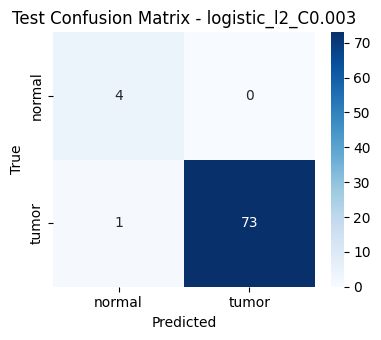


DONE
Best model: logistic_l2_C0.003
Threshold: 0.040503242518162216
Strict test metrics:
{
  "accuracy": 0.9871794871794872,
  "balanced_accuracy": 0.9932432432432432,
  "roc_auc": 1.0,
  "average_precision": 0.9999999999999998,
  "macro_f1": 0.9410430839002267,
  "confusion_matrix": [
    [
      4,
      0
    ],
    [
      1,
      73
    ]
  ]
}
Bootstrap 95% CI:
{
  "accuracy": {
    "mean": 0.9875310908830462,
    "ci95_low": 0.9615384615384616,
    "ci95_high": 1.0
  },
  "balanced_accuracy": {
    "mean": 0.9934207293337476,
    "ci95_low": 0.9791666666666667,
    "ci95_high": 1.0
  },
  "roc_auc": {
    "mean": 1.0,
    "ci95_low": 1.0,
    "ci95_high": 1.0
  },
  "macro_f1": {
    "mean": 0.9390710010244953,
    "ci95_low": 0.7756471716203259,
    "ci95_high": 1.0
  }
}

Saved to: /content/drive/MyDrive/drugtarget_local/outputs/ml_models


,gene_name_norm,model_importance,target_score,target_rank,evidence_level
0,PLA2G4E,0.023228,0.070876,16158,background
1,NCKAP5,0.020097,0.437681,961,background
2,GPM6A,0.019927,0.503257,394,exploratory
3,NTM,0.017534,0.448708,829,background
4,PYCR1,0.017045,0.519195,279,exploratory
5,GPA33,0.016514,0.416408,1304,background
6,PLA2G7,0.016096,0.246549,9010,background
7,MME,0.015109,0.450077,813,background
8,RTKN2,0.014914,0.451496,790,background
9,ARHGAP40,0.014437,0.434161,1010,background


In [ ]:
import json
import subprocess
import sys
import warnings
from pathlib import Path


OUTPUTS_DIR = Path("/content/drive/MyDrive/drugtarget_local/outputs")
ML_INPUTS_DIR = OUTPUTS_DIR / "ml_inputs"
ML_MODELS_DIR = OUTPUTS_DIR / "ml_models"
RANDOM_STATE = 42


def setup_colab():
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except Exception as exc:
        print("Drive mount skipped or unavailable:", exc)

    packages = [
        "pandas",
        "numpy",
        "pyarrow",
        "scikit-learn",
        "joblib",
        "matplotlib",
        "seaborn",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])


setup_colab()

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


warnings.filterwarnings("ignore", category=FutureWarning)
ML_MODELS_DIR.mkdir(parents=True, exist_ok=True)


def require_inputs():
    required = [
        ML_INPUTS_DIR / "X_train.parquet",
        ML_INPUTS_DIR / "X_val.parquet",
        ML_INPUTS_DIR / "X_test.parquet",
        ML_INPUTS_DIR / "y_train.parquet",
        ML_INPUTS_DIR / "y_val.parquet",
        ML_INPUTS_DIR / "y_test.parquet",
        ML_INPUTS_DIR / "target_prioritization_features.parquet",
    ]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing ML input files:\n" + "\n".join(missing))


def load_split(split: str):
    x = pd.read_parquet(ML_INPUTS_DIR / f"X_{split}.parquet")
    y_frame = pd.read_parquet(ML_INPUTS_DIR / f"y_{split}.parquet")
    y = y_frame.set_index("file_id").reindex(x.index)["label"].astype(int)
    return x, y, y_frame


def predict_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(x)
        return 1 / (1 + np.exp(-scores))
    raise TypeError("Model has neither predict_proba nor decision_function.")


def threshold_from_validation(y_true, score, metric="balanced_accuracy"):
    thresholds = np.unique(np.quantile(score, np.linspace(0.02, 0.98, 97)))
    best_threshold = 0.5
    best_value = -np.inf
    rows = []
    for threshold in thresholds:
        pred = (score >= threshold).astype(int)
        if metric == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif metric == "macro_f1":
            value = f1_score(y_true, pred, average="macro", zero_division=0)
        else:
            raise ValueError(metric)
        rows.append({"threshold": float(threshold), metric: float(value)})
        if value > best_value:
            best_value = value
            best_threshold = float(threshold)
    return best_threshold, pd.DataFrame(rows)


def evaluate_scores(y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "roc_auc": float(roc_auc_score(y_true, score)),
        "average_precision": float(average_precision_score(y_true, score)),
        "macro_f1": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "normal_precision": float(precision_score(y_true, pred, pos_label=0, zero_division=0)),
        "normal_recall": float(recall_score(y_true, pred, pos_label=0, zero_division=0)),
        "tumor_precision": float(precision_score(y_true, pred, pos_label=1, zero_division=0)),
        "tumor_recall": float(recall_score(y_true, pred, pos_label=1, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, pred, labels=[0, 1]).tolist(),
        "classification_report": classification_report(
            y_true,
            pred,
            labels=[0, 1],
            target_names=["normal", "tumor"],
            output_dict=True,
            zero_division=0,
        ),
    }


def make_candidate_models():
    candidates = {}

    for c in [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]:
        candidates[f"logistic_l2_C{c}"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        C=c,
                        penalty="l2",
                        solver="liblinear",
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        max_iter=3000,
                    ),
                ),
            ]
        )

    for c in [0.003, 0.01, 0.03, 0.1, 0.3]:
        for l1_ratio in [0.15, 0.5, 0.85]:
            candidates[f"logistic_elasticnet_C{c}_l1{l1_ratio}"] = Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                    (
                        "model",
                        LogisticRegression(
                            C=c,
                            penalty="elasticnet",
                            solver="saga",
                            l1_ratio=l1_ratio,
                            class_weight="balanced",
                            random_state=RANDOM_STATE,
                            max_iter=5000,
                            n_jobs=-1,
                        ),
                    ),
                ]
            )

    for c in [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]:
        linear_svc = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LinearSVC(
                        C=c,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        max_iter=5000,
                        dual="auto",
                    ),
                ),
            ]
        )
        candidates[f"calibrated_linear_svc_C{c}"] = CalibratedClassifierCV(linear_svc, cv=3, method="sigmoid")

    for max_depth in [4, 6, 8]:
        candidates[f"random_forest_depth{max_depth}"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=600,
                        max_depth=max_depth,
                        min_samples_leaf=3,
                        max_features="sqrt",
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

    for max_depth in [4, 6, 8, None]:
        candidates[f"extra_trees_depth{max_depth}"] = Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=800,
                        max_depth=max_depth,
                        min_samples_leaf=2,
                        max_features="sqrt",
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        )

    return candidates


def model_complexity_penalty(name):
    if name.startswith("logistic_l2"):
        return 0.000
    if name.startswith("logistic_elasticnet"):
        return 0.002
    if name.startswith("calibrated_linear_svc"):
        return 0.004
    if name.startswith("random_forest"):
        return 0.010
    if name.startswith("extra_trees"):
        return 0.012
    return 0.020


def train_and_select_models(x_train, y_train, x_val, y_val):
    print("Training candidate models...")
    candidates = make_candidate_models()
    results = []
    fitted = {}
    threshold_tables = {}

    for i, (name, model) in enumerate(candidates.items(), 1):
        print(f"  [{i:02d}/{len(candidates)}] {name}")
        fitted_model = clone(model)
        fitted_model.fit(x_train, y_train)
        val_score = predict_scores(fitted_model, x_val)
        threshold, threshold_table = threshold_from_validation(y_val, val_score, metric="balanced_accuracy")
        metrics = evaluate_scores(y_val, val_score, threshold)
        row = {
            "model_name": name,
            "selection_score": metrics["balanced_accuracy"] + 0.02 * metrics["roc_auc"] - model_complexity_penalty(name),
            **{k: v for k, v in metrics.items() if k not in ["classification_report", "confusion_matrix"]},
            "confusion_matrix": json.dumps(metrics["confusion_matrix"]),
        }
        results.append(row)
        fitted[name] = fitted_model
        threshold_tables[name] = threshold_table

    leaderboard = pd.DataFrame(results).sort_values(
        ["selection_score", "balanced_accuracy", "roc_auc", "macro_f1"],
        ascending=False,
    )
    leaderboard.to_csv(ML_MODELS_DIR / "validation_leaderboard.csv", index=False)
    best_name = leaderboard.iloc[0]["model_name"]
    print("\nBest model by validation:", best_name)
    display(leaderboard.head(15))
    return best_name, fitted[best_name], leaderboard, threshold_tables[best_name]


def fit_final_model(best_model, x_train, y_train, x_val, y_val):
    x_train_val = pd.concat([x_train, x_val], axis=0)
    y_train_val = pd.concat([y_train, y_val], axis=0)
    final_model = clone(best_model)
    final_model.fit(x_train_val, y_train_val)
    val_score = predict_scores(best_model, x_val)
    best_threshold, threshold_table = threshold_from_validation(y_val, val_score, metric="balanced_accuracy")
    return final_model, best_threshold, threshold_table


def bootstrap_metric_ci(y_true, score, threshold, n_boot=2000):
    rng = np.random.default_rng(RANDOM_STATE)
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    rows = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        pred = (score[idx] >= threshold).astype(int)
        rows.append(
            {
                "accuracy": accuracy_score(y_true[idx], pred),
                "balanced_accuracy": balanced_accuracy_score(y_true[idx], pred),
                "roc_auc": roc_auc_score(y_true[idx], score[idx]),
                "macro_f1": f1_score(y_true[idx], pred, average="macro", zero_division=0),
            }
        )
    frame = pd.DataFrame(rows)
    return {
        metric: {
            "mean": float(frame[metric].mean()),
            "ci95_low": float(frame[metric].quantile(0.025)),
            "ci95_high": float(frame[metric].quantile(0.975)),
        }
        for metric in frame.columns
    }


def extract_feature_importance(model, x_train, y_train, x_test, y_test, model_name):
    print("Extracting feature importance...")
    feature_names = list(x_train.columns)
    importance = pd.DataFrame({"gene_name_norm": feature_names})

    fitted = model
    if isinstance(model, Pipeline):
        final_step = model.named_steps.get("model")
    else:
        final_step = None

    if final_step is not None and hasattr(final_step, "coef_"):
        coef = final_step.coef_[0]
        importance["coefficient"] = coef
        importance["model_importance"] = np.abs(coef)
        importance["importance_type"] = "absolute_coefficient"
    elif final_step is not None and hasattr(final_step, "feature_importances_"):
        importance["model_importance"] = final_step.feature_importances_
        importance["importance_type"] = "tree_feature_importance"
    else:
        # Calibrated SVC and other wrappers: use permutation importance on test.
        perm = permutation_importance(
            fitted,
            x_test,
            y_test,
            scoring="balanced_accuracy",
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        importance["model_importance"] = perm.importances_mean
        importance["importance_std"] = perm.importances_std
        importance["importance_type"] = "test_permutation_balanced_accuracy"

    target_features = pd.read_parquet(ML_INPUTS_DIR / "target_prioritization_features.parquet")
    importance = importance.merge(target_features, on="gene_name_norm", how="left")
    importance = importance.sort_values("model_importance", ascending=False).reset_index(drop=True)
    importance["model_importance_rank"] = np.arange(1, len(importance) + 1)
    importance.to_parquet(ML_MODELS_DIR / "best_model_feature_importance_joined.parquet", index=False)
    importance.head(100).to_csv(ML_MODELS_DIR / "top_100_model_features_joined.csv", index=False)
    return importance


def plot_confusion_matrix(cm, title, output_path):
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(
        np.array(cm),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["normal", "tumor"],
        yticklabels=["normal", "tumor"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()


def main():
    require_inputs()
    x_train, y_train, train_meta = load_split("train")
    x_val, y_val, val_meta = load_split("val")
    x_test, y_test, test_meta = load_split("test")

    print("Shapes:")
    print("  X_train:", x_train.shape, y_train.value_counts().to_dict())
    print("  X_val:  ", x_val.shape, y_val.value_counts().to_dict())
    print("  X_test: ", x_test.shape, y_test.value_counts().to_dict())

    best_name, best_model, leaderboard, threshold_table = train_and_select_models(x_train, y_train, x_val, y_val)
    threshold_table.to_csv(ML_MODELS_DIR / "best_model_validation_thresholds.csv", index=False)

    # Strict report: the selected model remains fit on train only.
    # Validation chooses model and threshold; test is evaluated once.
    val_score = predict_scores(best_model, x_val)
    threshold, _ = threshold_from_validation(y_val, val_score, metric="balanced_accuracy")
    strict_test_score = predict_scores(best_model, x_test)
    strict_test_metrics = evaluate_scores(y_test, strict_test_score, threshold)
    strict_test_ci = bootstrap_metric_ci(y_test, strict_test_score, threshold)
    strict_train_score = predict_scores(best_model, x_train)
    strict_train_metrics = evaluate_scores(y_train, strict_train_score, threshold)
    strict_val_metrics = evaluate_scores(y_val, val_score, threshold)

    # Deployment model: after strict test reporting, refit same selected class on train+validation.
    # Do not use this refit model to claim test metrics.
    deployment_model, deployment_threshold, _ = fit_final_model(best_model, x_train, y_train, x_val, y_val)

    joblib.dump(
        {
            "model": best_model,
            "model_name": best_name,
            "threshold": threshold,
            "features": list(x_train.columns),
            "label_mapping": {"normal": 0, "tumor": 1},
            "protocol": "strict_train_only_model_validation_threshold",
        },
        ML_MODELS_DIR / "best_tumor_normal_model_strict.joblib",
    )
    joblib.dump(
        {
            "model": deployment_model,
            "model_name": best_name,
            "threshold": deployment_threshold,
            "features": list(x_train.columns),
            "label_mapping": {"normal": 0, "tumor": 1},
            "protocol": "deployment_refit_train_plus_validation",
        },
        ML_MODELS_DIR / "best_tumor_normal_model_deployment.joblib",
    )

    importance = extract_feature_importance(best_model, x_train, y_train, x_test, y_test, best_name)

    metrics = {
        "project": "Drug Target Identification using Multi-omics Data & PPI Networks",
        "task": "TCGA-LUAD tumor-vs-normal classifier",
        "best_model_name": best_name,
        "selection_protocol": "Candidate models selected on validation split; strict test metrics use the train-only fitted model.",
        "threshold_protocol": "Classification threshold selected on validation split for balanced accuracy.",
        "threshold": float(threshold),
        "data_shapes": {
            "train": list(x_train.shape),
            "validation": list(x_val.shape),
            "test": list(x_test.shape),
            "deployment_train_val": [int(x_train.shape[0] + x_val.shape[0]), int(x_train.shape[1])],
        },
        "class_counts": {
            "train": {str(k): int(v) for k, v in y_train.value_counts().to_dict().items()},
            "validation": {str(k): int(v) for k, v in y_val.value_counts().to_dict().items()},
            "test": {str(k): int(v) for k, v in y_test.value_counts().to_dict().items()},
        },
        "strict_train_metrics": strict_train_metrics,
        "strict_validation_metrics": strict_val_metrics,
        "strict_test_metrics": strict_test_metrics,
        "strict_test_bootstrap_ci": strict_test_ci,
        "deployment_note": "A second model refit on train+validation is saved for deployment only; reported test metrics are from the strict train-only model.",
        "top_30_features": importance.head(30).replace({np.nan: None}).to_dict(orient="records"),
    }
    (ML_MODELS_DIR / "best_model_metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    plot_confusion_matrix(
        strict_test_metrics["confusion_matrix"],
        f"Test Confusion Matrix - {best_name}",
        ML_MODELS_DIR / "test_confusion_matrix.png",
    )

    print("\nDONE")
    print("Best model:", best_name)
    print("Threshold:", threshold)
    print("Strict test metrics:")
    print(json.dumps({k: strict_test_metrics[k] for k in ["accuracy", "balanced_accuracy", "roc_auc", "average_precision", "macro_f1", "confusion_matrix"]}, indent=2))
    print("Bootstrap 95% CI:")
    print(json.dumps(strict_test_ci, indent=2))
    print("\nSaved to:", ML_MODELS_DIR)
    display(importance[["gene_name_norm", "model_importance", "target_score", "target_rank", "evidence_level"]].head(30))


main()


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler


OUTPUTS = Path("/content/drive/MyDrive/drugtarget_local/outputs")
ML_MODELS = OUTPUTS / "ml_models"
BIO_EVIDENCE = OUTPUTS / "biological_evidence"
ML_INPUTS = OUTPUTS / "ml_inputs"
ML_MODELS.mkdir(parents=True, exist_ok=True)

PROTEIN_TARGET_NAMES = {
    "PLK1": "Polo-like kinase 1",
    "AURKB": "Aurora kinase B",
    "TOP2A": "DNA topoisomerase II alpha",
    "CCNB1": "Cyclin B1",
    "CCNB2": "Cyclin B2",
    "CCNA2": "Cyclin A2",
    "CDC20": "Cell division cycle protein 20 homolog",
    "BIRC5": "Survivin",
    "UBE2C": "Ubiquitin-conjugating enzyme E2 C",
    "CENPA": "Histone H3-like centromeric protein A",
    "SPP1": "Osteopontin",
    "CAV1": "Caveolin-1",
    "COL1A1": "Collagen alpha-1(I) chain",
    "KIF20A": "Kinesin-like protein KIF20A",
}


def read_table(path):
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path) if path.suffix == ".csv" else pd.read_parquet(path)


def minmax(series):
    values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if values.notna().sum() == 0:
        return pd.Series(np.zeros(len(values)), index=values.index)
    lo, hi = values.min(), values.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        return pd.Series(np.zeros(len(values)), index=values.index)
    return ((values - lo) / (hi - lo)).clip(0, 1).fillna(0)


def percentile_score(values):
    series = pd.Series(values).replace([np.inf, -np.inf], np.nan)
    series = series.fillna(series.median())
    return series.rank(method="average", pct=True).to_numpy()


def load_feature_table():
    enriched = read_table(BIO_EVIDENCE / "target_evidence_enriched.parquet")
    target_features = read_table(ML_INPUTS / "target_prioritization_features.parquet")
    master = read_table(OUTPUTS / "master_biomarker_features.parquet")
    importance = read_table(ML_MODELS / "best_model_feature_importance_joined.parquet")
    if importance.empty:
        importance = read_table(ML_INPUTS / "model_feature_importance_joined.parquet")

    base = enriched if not enriched.empty else target_features
    if base.empty:
        base = master
    if base.empty or "gene_name_norm" not in base.columns:
        raise FileNotFoundError("No target feature table found under outputs/.")

    frame = base.copy()
    frame["gene_name_norm"] = frame["gene_name_norm"].astype(str).str.upper().str.strip()

    for extra in [target_features, master, importance]:
        if extra.empty or "gene_name_norm" not in extra.columns:
            continue
        extra = extra.copy()
        extra["gene_name_norm"] = extra["gene_name_norm"].astype(str).str.upper().str.strip()
        keep = [c for c in extra.columns if c == "gene_name_norm" or c not in frame.columns]
        frame = frame.merge(extra[keep], on="gene_name_norm", how="left")

    return frame.drop_duplicates("gene_name_norm").reset_index(drop=True)


frame = load_feature_table()
feature_candidates = [
    "gdc_abs_log2_fc",
    "gdc_neg_log10_fdr",
    "gdc_neg_log10_p",
    "target_score",
    "integrated_evidence_score",
    "expression_component",
    "network_component",
    "validation_component",
    "druggability_score",
    "model_component",
    "survival_component",
    "degree_gene",
    "weighted_degree_gene",
    "pagerank",
    "betweenness_centrality",
    "geo_validation_bonus",
    "geo_component_score",
    "model_importance",
    "survival_time_neg_log10_fdr",
]
feature_cols = [c for c in feature_candidates if c in frame.columns]
if len(feature_cols) < 5:
    raise ValueError(f"Too few usable protein target features: {feature_cols}")

x = frame[feature_cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
n = len(x)
n_clusters = int(np.clip(round(np.sqrt(n / 2)), 4, 12))
contamination = float(np.clip(80 / max(n, 1), 0.03, 0.12))
gmm_components = int(np.clip(n_clusters // 2, 2, 6))

print("Training unsupervised protein target ranker...")
print("targets:", n, "| features:", len(feature_cols), "| clusters:", n_clusters)

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
x_scaled = preprocess.fit_transform(x)

pca_components = min(12, x_scaled.shape[1], max(2, x_scaled.shape[0] - 1))
pca = PCA(n_components=pca_components, random_state=42)
x_pca = pca.fit_transform(x_scaled)

isolation = IsolationForest(
    n_estimators=600,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)
isolation.fit(x_pca)
isolation_priority = percentile_score(-isolation.score_samples(x_pca))

kmeans = KMeans(n_clusters=n_clusters, n_init=30, random_state=42)
clusters = kmeans.fit_predict(x_pca)

gmm = GaussianMixture(n_components=gmm_components, covariance_type="full", random_state=42, reg_covar=1e-5)
gmm.fit(x_pca)
gmm_rarity = percentile_score(-gmm.score_samples(x_pca))

evidence_parts = []
for col in [
    "target_score",
    "integrated_evidence_score",
    "gdc_abs_log2_fc",
    "gdc_neg_log10_fdr",
    "network_component",
    "druggability_score",
    "model_importance",
]:
    if col in frame.columns:
        evidence_parts.append(minmax(frame[col]))
evidence_prior = np.mean(np.vstack([p.to_numpy() for p in evidence_parts]), axis=0) if evidence_parts else np.zeros(n)

cluster_table = pd.DataFrame({"cluster": clusters, "evidence_prior": evidence_prior})
cluster_priority_map = cluster_table.groupby("cluster")["evidence_prior"].mean().rank(pct=True).to_dict()
cluster_priority = np.array([cluster_priority_map[c] for c in clusters])

raw_score = (
    0.34 * isolation_priority
    + 0.24 * gmm_rarity
    + 0.24 * cluster_priority
    + 0.18 * evidence_prior
)

ranking = frame.copy()
ranking["encoded_by_gene"] = ranking["gene_name_norm"]
ranking["protein_target"] = ranking["gene_name_norm"].map(lambda g: PROTEIN_TARGET_NAMES.get(g, f"{g} protein"))
ranking["protein_target_cluster"] = clusters.astype(int)
ranking["isolation_priority_score"] = isolation_priority
ranking["gmm_rarity_score"] = gmm_rarity
ranking["cluster_priority_score"] = cluster_priority
ranking["evidence_prior_score"] = evidence_prior
ranking["protein_ml_priority_score"] = minmax(pd.Series(raw_score)).to_numpy()
ranking["protein_ml_rank"] = ranking["protein_ml_priority_score"].rank(method="dense", ascending=False).astype(int)
ranking = ranking.sort_values(["protein_ml_rank", "target_rank"], na_position="last").reset_index(drop=True)

bundle = {
    "task": "unsupervised_protein_target_prioritization",
    "feature_cols": feature_cols,
    "preprocess": preprocess,
    "pca": pca,
    "isolation_forest": isolation,
    "kmeans": kmeans,
    "gmm": gmm,
    "score_formula": "0.34*isolation + 0.24*gmm_rarity + 0.24*cluster_priority + 0.18*evidence_prior",
    "n_targets": int(n),
    "n_clusters": int(n_clusters),
    "contamination": contamination,
    "interpretation": "Ranks candidate protein targets from multi-omics and STRING PPI feature profiles without target/non-target labels.",
}
summary = {
    "task": bundle["task"],
    "n_targets": int(n),
    "n_features": len(feature_cols),
    "feature_cols": feature_cols,
    "n_clusters": int(n_clusters),
    "contamination": contamination,
    "top_30": ranking[
        [
            "protein_ml_rank",
            "protein_target",
            "encoded_by_gene",
            "protein_ml_priority_score",
            "protein_target_cluster",
            *[c for c in ["target_rank", "target_score", "integrated_evidence_score", "druggability_class"] if c in ranking.columns],
        ]
    ].head(30).to_dict(orient="records"),
}

ranking.to_parquet(ML_MODELS / "protein_target_ranking.parquet", index=False)
ranking.to_csv(ML_MODELS / "protein_target_ranking.csv", index=False)
ranking.head(100).to_csv(ML_MODELS / "top_100_protein_target_ranking.csv", index=False)
joblib.dump(bundle, ML_MODELS / "protein_target_ranker.joblib")
with (ML_MODELS / "protein_target_ranker_summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nDONE")
print("Saved model:", ML_MODELS / "protein_target_ranker.joblib")
print("Saved ranking:", ML_MODELS / "protein_target_ranking.csv")
display(ranking[[
    "protein_ml_rank",
    "protein_target",
    "encoded_by_gene",
    "protein_ml_priority_score",
    "protein_target_cluster",
    *[c for c in ["target_rank", "target_score", "integrated_evidence_score", "druggability_class"] if c in ranking.columns],
]].head(30))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training unsupervised protein target ranker...
targets: 16861 | features: 11 | clusters: 12

DONE
Saved model: /content/drive/MyDrive/drugtarget_local/outputs/ml_models/protein_target_ranker.joblib
Saved ranking: /content/drive/MyDrive/drugtarget_local/outputs/ml_models/protein_target_ranking.csv


,protein_ml_rank,protein_target,encoded_by_gene,protein_ml_priority_score,protein_target_cluster,target_rank,target_score
0,1,IL6 protein,IL6,1.000000,9,297,0.516907
1,2,MME protein,MME,0.983646,3,813,0.450077
2,3,CDK1 protein,CDK1,0.983475,9,342,0.512199
3,4,Cell division cycle protein 20 homolog,CDC20,0.977182,3,3,0.611913
4,5,EXO1 protein,EXO1,0.969728,3,9,0.603288
5,6,Cyclin B1,CCNB1,0.966673,3,2,0.615296
6,7,Osteopontin,SPP1,0.960027,4,18,0.595321
7,8,CDKN2A protein,CDKN2A,0.946311,6,127,0.566107
8,9,EEF1A2 protein,EEF1A2,0.941573,4,114,0.572650
9,10,JUN protein,JUN,0.940205,3,409,0.501746
